## Identify potential extreme rainfall events from GloFAS reforecast data

- Read in data from 2003 to 2023 
- 10 ensemble members per forecast
- Forecasts run every 2-3 days on average 
- Lead time T+0 through to T+240 (10-day)

In [1]:
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import logging
from pathlib import Path
import time

In [20]:
# # logging
# logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")

# # CONFIG - adjust as needed
# ROOT = Path("/mnt/metdata/W25-2348/glofas")
# OUTPUT_DIR = ROOT / "processed_spread"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# YEARS = list(range(2014, 2024))   # default years 2003..2023 inclusive
# # Or use a custom list e.g. YEARS = [2019, 2022, 2023]
# # YEARS = [2019, 2022, 2023]

# GRIB_FILENAME = "data.grib"       # file inside each monthly folder (20xx_01/data.grib)
# VARIABLE = "dis24"                # the variable name in your files
# SPATIAL_DIMS = ["latitude", "longitude"]
# ENSEMBLE_DIM = "number"
# STEP_DIM = "step"
# TIME_DIM = "time"

# def find_year_files(year):
#     """Return sorted list of monthly GRIB files for given year directory"""
#     pattern = str(ROOT / f"{year}" / f"cems-glofas-reforecast_{year}_*" / GRIB_FILENAME)
#     files = sorted(glob.glob(pattern))
#     return files

# find_year_files(2023)

In [5]:
# logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")

# CONFIG - adjust as needed
ROOT = Path("/mnt/metdata/W25-2348/glofas")
OUTPUT_DIR = ROOT / "processed_spread"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#YEARS = list(range(2014, 2023))   # default years 2003..2023 inclusive
# Or use a custom list e.g. YEARS = [2019, 2022, 2023]
YEARS = [2004,2013]

GRIB_FILENAME = "data.grib"       # file inside each monthly folder (20xx_01/data.grib)
VARIABLE = "dis24"                # the variable name in your files
SPATIAL_DIMS = ["latitude", "longitude"]
ENSEMBLE_DIM = "number"
STEP_DIM = "step"
TIME_DIM = "time"

def find_year_files(year):
    """Return sorted list of monthly GRIB files for given year directory"""
    pattern = str(ROOT / f"{year}" / f"cems-glofas-reforecast_{year}_*" / GRIB_FILENAME)
    files = sorted(glob.glob(pattern))
    return files


def open_year_dataset(files):
    """ 
    Try to open files using 'mfdataset', otherwise open individually and concat 
    """
    if not files:
        raise FileNotFoundError("No files found for year")
    
    try:
        # attempt fast merge
        logging.info("Trying xr.open_mfdataset on %d files ...", len(files))
        ds = xr.open_mfdataset(files, 
                               engine='cfgrib', 
                               combine='by_coords',
                               parallel=True,
                               backend_kwargs={'indexpath': ''})
        return ds
    except Exception as e:
        logging.warning("open_mfdataset failed: %s. Falling back to per-file open+concat.", e)

    # fallback: open each file separately, optionally preprocess, then concat
    datasets = []
    for f in files:
        logging.info("Opening %s", f)
        dsf = xr.open_dataset(f, engine='cfgrib', backend_kwargs={"indexpath": ""})  # per-file open
        datasets.append(dsf)

    # concat on time (ensure each ds has a 'time' coordinate)
    ds = xr.concat(datasets, dim='time', data_vars='minimal', coords='minimal', combine_attrs='override')
    return ds


def compute_spread_for_year(year, out_dir=OUTPUT_DIR, overwrite=False):
    files = find_year_files(year)
    if not files:
        logging.warning("No files for year %s -> skipping", year)
        return None

    outpath = out_dir / f"glofas_spread_{year}.nc"
    if outpath.exists() and not overwrite:
        logging.info("Output exists for %s -> %s (skip). Use overwrite=True to replace.", year, outpath)
        return outpath

    ds = open_year_dataset(files)
    if VARIABLE not in ds:
        raise KeyError(f"Variable {VARIABLE} not found in dataset variables: {list(ds.keys())}")

    da = ds[VARIABLE].sel(latitude=53.375,method='nearest').sel(longitude=353.625,method='nearest')

    # # Spatial average to remove lat/lon
    # if all(dim in da.dims for dim in SPATIAL_DIMS):
    #     da = da.mean(dim=SPATIAL_DIMS)  # dims: (number, time, step)
    # else:
    #     logging.warning("One of spatial dims %s not in da.dims %s; skipping spatial mean",
    #                     SPATIAL_DIMS, da.dims)

    # Ensure dims order we expect (number, time, step)
    # We will use .isel(step=...) which expects step present
    logging.info("After selecting single grid point, dims = %s", da.dims)

    # get dims sizes and coords
    nstep = da.sizes.get(STEP_DIM)
    ntime = da.sizes.get(TIME_DIM)
    if nstep is None or ntime is None:
        raise ValueError("Expected dims 'step' and 'time' in data array after spatial averaging")

    times = da[TIME_DIM].values
    steps = da[STEP_DIM].values

    # Prepare arrays to hold results: shape (time, step)
    q25_arr = np.full((ntime, nstep), np.nan, dtype=np.float32)
    q50_arr = np.full((ntime, nstep), np.nan, dtype=np.float32)
    q75_arr = np.full((ntime, nstep), np.nan, dtype=np.float32)
    spread_maxmin_arr = np.full((ntime, nstep), np.nan, dtype=np.float32)

    logging.info("Computing percentiles for year %s: nstep=%d ntime=%d", year, nstep, ntime)

    # Loop over steps - each step we bring a small (ensemble x time) array into memory
    for si in range(nstep):
        t0 = time.time()
        da_step = da.isel({STEP_DIM: si})  # dims: (number, time)
        # compute to numpy array in memory (small: ensemble ~10, time ~175)
        arr = da_step.data
        if hasattr(arr, "compute"):
            arr = arr.compute()   # returns numpy array
        else:
            arr = np.asarray(arr)

        # shape should be (number, time)
        if arr.ndim != 2:
            # try to squeeze or transpose if needed
            arr = np.squeeze(arr)
            if arr.ndim != 2:
                raise ValueError(f"Unexpected arr shape for step {si}: {arr.shape}")

        # compute percentiles across ensemble axis (axis=0)
        # use nanpercentile to be robust to missing values
        q25 = np.nanpercentile(arr, 25, axis=0)
        q50 = np.nanpercentile(arr, 50, axis=0)
        q75 = np.nanpercentile(arr, 75, axis=0)
        maxv = np.nanmax(arr, axis=0)
        minv = np.nanmin(arr, axis=0)
        spread_mm = maxv - minv

        # store
        q25_arr[:, si] = q25.astype(np.float32)
        q50_arr[:, si] = q50.astype(np.float32)
        q75_arr[:, si] = q75.astype(np.float32)
        spread_maxmin_arr[:, si] = spread_mm.astype(np.float32)

        logging.info("  step %d/%d done in %.2f s", si + 1, nstep, time.time() - t0)

    # Build xarray Dataset for output
    out_ds = xr.Dataset(
        {
            "q25": (("time", "step"), q25_arr),
            "q50": (("time", "step"), q50_arr),
            "q75": (("time", "step"), q75_arr),
            "spread_maxmin": (("time", "step"), spread_maxmin_arr),
        },
        coords={
            "time": times,
            "step": steps,
        },
        attrs={
            "source": "computed from dis24, averaged over latitude/longitude",
            "year": int(year),
        },
    )

    # Save to netcdf
    logging.info("Saving output to %s", outpath)
    encoding = {var: {"zlib": True, "complevel": 4} for var in out_ds.data_vars}
    out_ds.to_netcdf(outpath, format="NETCDF4", encoding=encoding)
    logging.info("Saved %s", outpath)
    return outpath


def main(years=YEARS):
    for y in years:
        try:
            compute_spread_for_year(y)
        except Exception as e:
            logging.exception("Failed processing year %s: %s", y, e)


if __name__ == "__main__":
    main()

2025-11-03 12:26:42,949 INFO: Trying xr.open_mfdataset on 12 files ...


2025-11-03 12:27:41,204 INFO: After selecting single grid point, dims = ('number', 'time', 'step')
2025-11-03 12:27:41,216 INFO: Computing percentiles for year 2004: nstep=9 ntime=175
2025-11-03 12:30:38,427 INFO:   step 1/9 done in 177.21 s
2025-11-03 12:33:14,594 INFO:   step 2/9 done in 156.17 s
2025-11-03 12:35:54,016 INFO:   step 3/9 done in 159.42 s
2025-11-03 12:38:26,835 INFO:   step 4/9 done in 152.82 s
2025-11-03 12:41:06,355 INFO:   step 5/9 done in 159.52 s
2025-11-03 12:43:37,843 INFO:   step 6/9 done in 151.49 s
2025-11-03 12:46:14,371 INFO:   step 7/9 done in 156.53 s
2025-11-03 12:48:53,073 INFO:   step 8/9 done in 158.70 s
2025-11-03 12:51:29,394 INFO:   step 9/9 done in 156.32 s
2025-11-03 12:51:29,397 INFO: Saving output to /mnt/metdata/W25-2348/glofas/processed_spread/glofas_spread_2004.nc
2025-11-03 12:51:29,455 INFO: Saved /mnt/metdata/W25-2348/glofas/processed_spread/glofas_spread_2004.nc
2025-11-03 12:51:29,486 INFO: Trying xr.open_mfdataset on 12 files ...
2025

### Analyse each reforecast 

- For all lead times (T+0, T+24, ..., T+240), calculate the ensemble spread 
- 25th, 50th, 75th percentile, [max-min]?
- Focus on a representative location along the River Liffey (see summary doc: https://jbagrp-my.sharepoint.com/:w:/r/personal/sam_hardy_jbaconsulting_com/_layouts/15/Doc.aspx?sourcedoc=%7B0FAE4B8C-5A00-4D81-B53A-0F4226F5CB30%7D&file=W25-3248_Earth2_Digital_Twin_Initiative.docx&action=default&mobileredirect=true)

In [ ]:
# da = ds['dis24'].sel(latitude=53.375,method='nearest').sel(longitude=353.625,method='nearest')

### Compute quantiles, max and min 

In [ ]:
# # 2) compute quantiles across ensemble members (dim='number'), keep 'step' dimension
# q25 = da.quantile(0.25, dim='number')   # dims -> time, step
# q50 = da.quantile(0.50, dim='number')   # median
# q75 = da.quantile(0.75, dim='number')

# # 3) also compute simple max-min spread across ensemble members (if you want)
# ens_max = da.max(dim='number')
# ens_min = da.min(dim='number')
# spread_maxmin = ens_max - ens_min     # dims -> time, step

### Produce a simple plot for a particular lead time

- Select a single lead time
    - 0: T+24
    - 1: T+48
    - 2: T+72
    - 3: T+96
    - 4: T+120 (5 days) --> look at this lead time first
    - 5: T+144
    - 6: T+168 (7 days)
    - 7: T+192
    - 8: T+216 (9 days)

In [ ]:
# step_idx = 4
# da_single_lead_time = da.isel(step=step_idx)
# array = da_single_lead_time.data.compute()

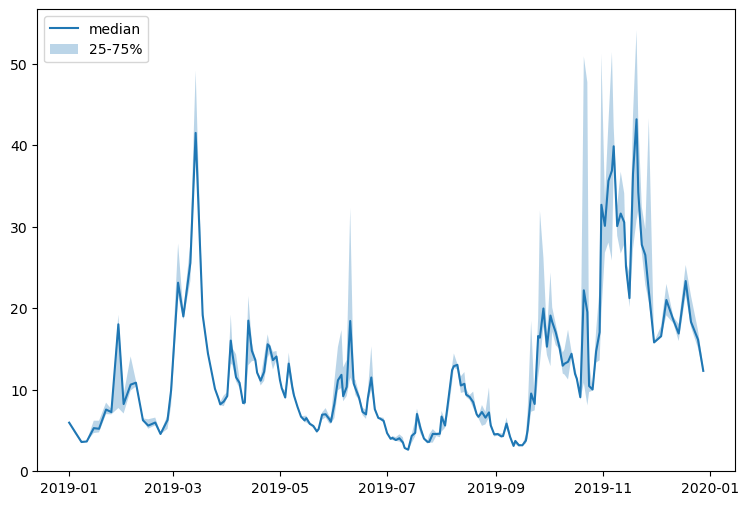

In [ ]:
# def plot_for_step(xr_da: xr.DataArray,
#                   np_arr: np.ndarray):
#     """ 
#     Produce a simple plot for a single lead time in our GloFAS reforecast data
#     """
#     # da_step = da.isel(step=step_idx)   # dims: number, time
#     # arr = da_step.data.compute()       # small: (10,175)

#     q25 = np.percentile(np_arr, 25, axis=0)
#     q50 = np.percentile(np_arr, 50, axis=0)
#     q75 = np.percentile(np_arr, 75, axis=0)

#     # ADD CODE TO CALCULATE [MAX-MIN] as a measure of ensemble spread
#     t = xr_da['time'].values

#     plt.figure(figsize=(9,6))
#     plt.plot(t, q50, label='median')
#     plt.fill_between(t, q25, q75, alpha=0.3, label='25-75%')
#     plt.legend(); plt.show()

# plot_for_step(da_single_lead_time,
#               array)  # choose step index of interest